Applied pressure offset: -0.05309238341968914 bar
CA10 = -3.1 deg
CA50 = 9.7 deg
CA90 = 25.5 deg
IMEP = 5.28812770493929 bar
Analysis results saved to analysis_results.txt


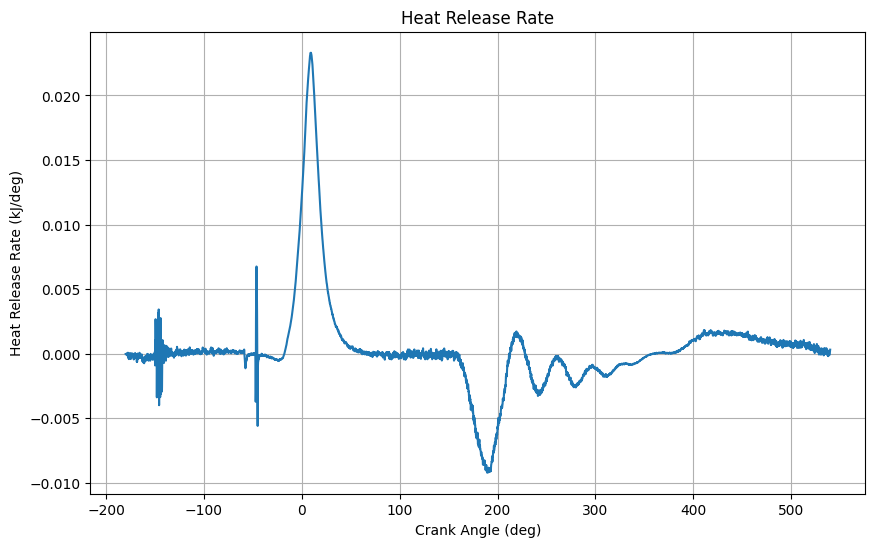

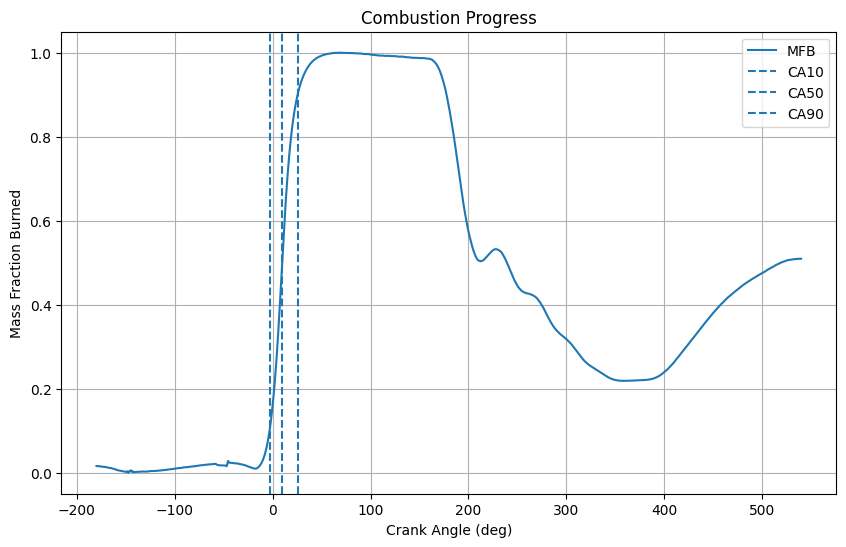

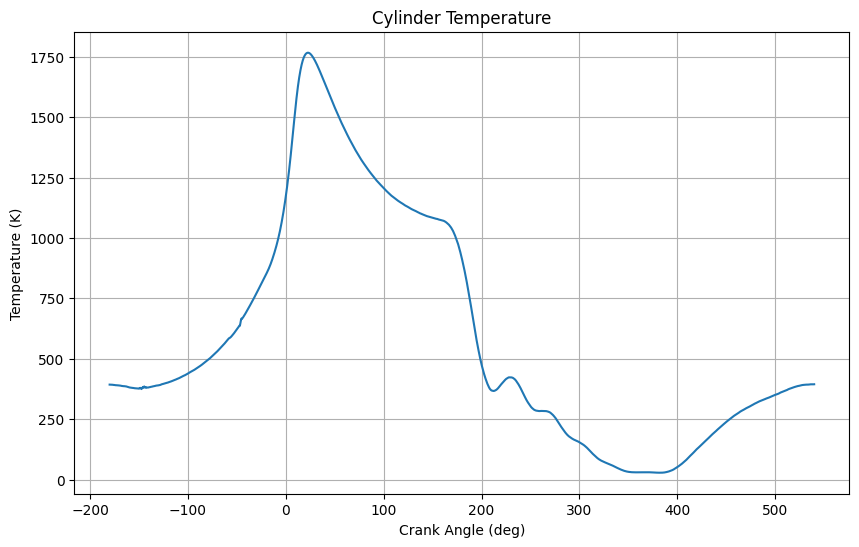

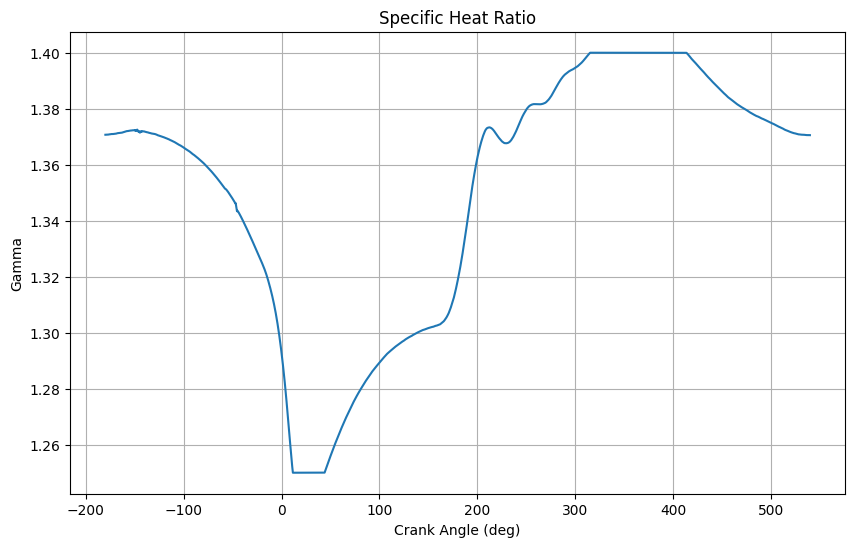

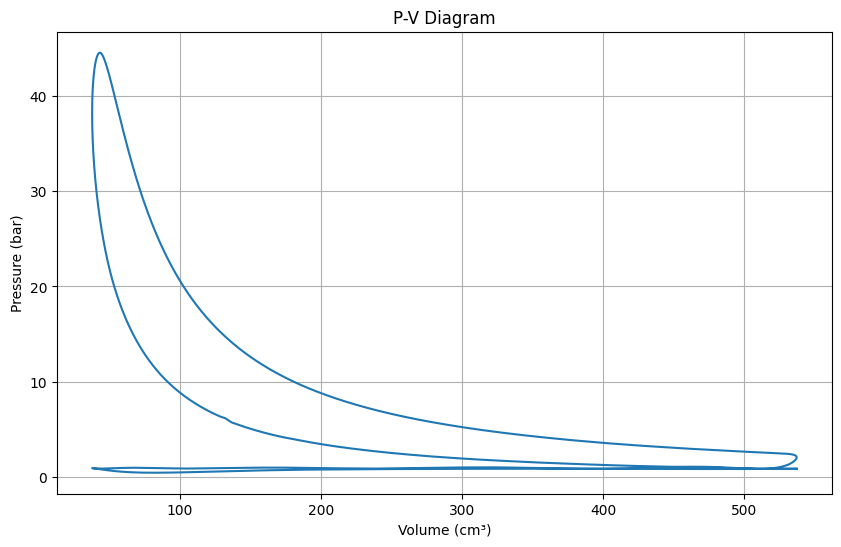

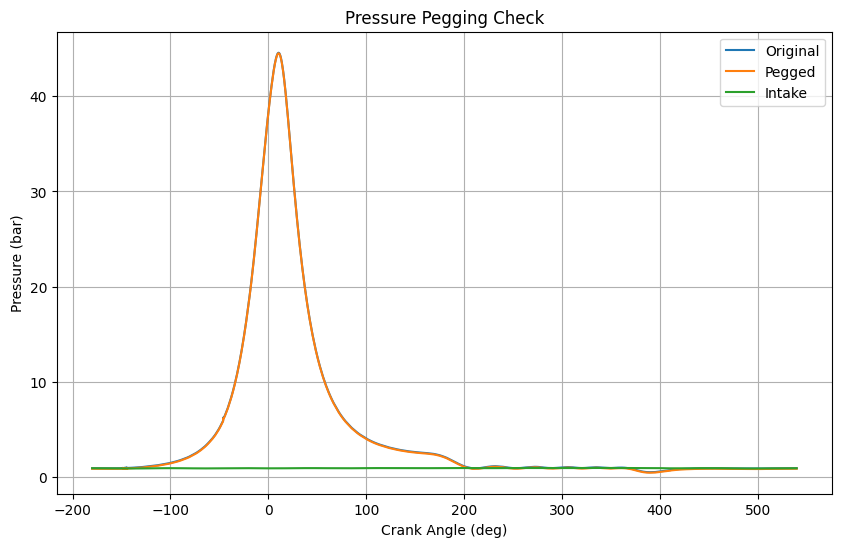

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# ENGINE PARAMETERS
# ------------------------------------------------

bore = 0.085
stroke = 0.088
conrod = 0.145
compression_ratio = 14.23

R = 287.0                  # gas constant (J/kg/K)

# ------------------------------------------------
# DERIVED GEOMETRY
# ------------------------------------------------

area = np.pi * (bore/2)**2
r = stroke / 2
l = conrod

Vs = area * stroke
Vc = Vs / (compression_ratio - 1)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

def cylinder_volume(theta_deg):
    theta = np.radians(theta_deg)
    x = r*(1 - np.cos(theta)) + (l - np.sqrt(l**2 - (r*np.sin(theta))**2))
    V = Vc + area*x
    return V

# ------------------------------------------------
# GAMMA(T) CORRELATION
# ------------------------------------------------

def gamma_temperature(T):
    gamma = 1.38 - 0.0001*(T - 300)
    gamma = np.clip(gamma, 1.25, 1.40)
    return gamma

# ------------------------------------------------
# MASS ESTIMATE AT IVC
# ------------------------------------------------

def estimate_mass(theta, p, V):
    T_ivc = 400.0  # assumed intake temperature (K)
    IVC = -122      # intake valve closing crank angle (deg)
    idx = np.argmin(np.abs(theta - IVC))
    p_ivc = p[idx]
    V_ivc = V[idx]
    m = p_ivc * V_ivc / (R * T_ivc)
    return m

# ------------------------------------------------
# COMBUSTION SOLVER
# ------------------------------------------------

def combustion_solver(theta, p, V):
    m = estimate_mass(theta, p, V)
    gamma = np.ones(len(theta)) * 1.35

    for iteration in range(5):
        dp_dtheta = np.gradient(p, theta)
        dV_dtheta = np.gradient(V, theta)
        HRR = (gamma/(gamma-1))*p*dV_dtheta + (1/(gamma-1))*V*dp_dtheta
        CHR = np.cumsum(HRR * np.gradient(theta))
        Q_total = np.max(CHR)
        xb = CHR / Q_total
        xb = np.clip(xb, 0, 1)
        T = p * V / (m * R)
        gamma = gamma_temperature(T)

    return HRR, CHR, xb, T, gamma

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

file_path = "AR_MT_251028_16h41m51s_13581.txt"
file_prefix = file_path.replace(".txt", "")
data = pd.read_csv(file_path, sep='\s+', comment="#")

theta = data["CAD[deg]"].to_numpy()
p_cyl_bar = data["p_cyl[bar]"].to_numpy()
p_intake_bar = data["p_intake[bar]"].to_numpy()

p_cyl = p_cyl_bar * 1e5
p_intake = p_intake_bar * 1e5

# ------------------------------------------------
# PRESSURE PEGGING
# ------------------------------------------------

peg_window = (theta > -180) & (theta < -122)
p_cyl_mean = np.mean(p_cyl[peg_window])
p_intake_mean = np.mean(p_intake[peg_window])
delta_p = p_intake_mean - p_cyl_mean
print("Applied pressure offset:", delta_p/1e5, "bar")
p_cyl_pegged = p_cyl + delta_p

# ------------------------------------------------
# PRESSURE FILTERING
# ------------------------------------------------

p_filtered = savgol_filter(p_cyl_pegged, 21, 3)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

V = cylinder_volume(theta)

# ------------------------------------------------
# COMBUSTION ANALYSIS
# ------------------------------------------------

HRR, CHR, xb, T, gamma = combustion_solver(theta, p_filtered, V)
CHR_norm = (CHR - np.min(CHR)) / (np.max(CHR) - np.min(CHR))

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

def find_CA(target):
    idx = np.where(CHR_norm >= target)[0][0]
    return theta[idx]

CA10 = find_CA(0.10)
CA50 = find_CA(0.50)
CA90 = find_CA(0.90)
print("CA10 =", CA10, "deg")
print("CA50 =", CA50, "deg")
print("CA90 =", CA90, "deg")

# ------------------------------------------------
# IMEP
# ------------------------------------------------

work = np.trapz(p_filtered, V)
IMEP = work / Vs
print("IMEP =", IMEP/1e5, "bar")

# ------------------------------------------------
# SAVE RESULTS TO FILE
# ------------------------------------------------

output_data = np.column_stack([theta, p_filtered, gamma, T, HRR, CHR])
header = "CAD[deg] p_filtered[Pa] gamma T[K] HRR[Pa*deg] CHR[Pa*deg]"
np.savetxt(file_prefix + "_analysis_results.txt", output_data, header=header, fmt="%.6e", comments='')
print("Analysis results saved to analysis_results.txt")

# ------------------------------------------------
# PLOTS (same as before)
# ------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(theta, HRR/1000)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Heat Release Rate (kJ/deg)")
plt.title("Heat Release Rate")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, CHR_norm, label="MFB")
plt.axvline(CA10, linestyle="--", label="CA10")
plt.axvline(CA50, linestyle="--", label="CA50")
plt.axvline(CA90, linestyle="--", label="CA90")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Mass Fraction Burned")
plt.title("Combustion Progress")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, T)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Temperature (K)")
plt.title("Cylinder Temperature")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, gamma)
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Gamma")
plt.title("Specific Heat Ratio")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(V*1e6, p_filtered/1e5)
plt.xlabel("Volume (cm³)")
plt.ylabel("Pressure (bar)")
plt.title("P-V Diagram")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, p_cyl_bar, label="Original")
plt.plot(theta, p_cyl_pegged/1e5, label="Pegged")
plt.plot(theta, p_intake_bar, label="Intake")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Pegging Check")
plt.legend()
plt.grid()
plt.show()

Fuel molar mass: 0.01703052
Fuel LHV: 18.6 MJ/kg
Air mass per cycle: 0.0003700683991368225
Fuel mass per cycle: 6.130813174460659e-05
Fuel energy per cycle: 1140.3312504496826
Temperature at IVC: 394.80592533599304
Best polytropic exponent: 1.3969849246231156
IMEP (bar): 6.538891912714314 bar
Thermal efficiency (%): 28.634099999216488
Combustion efficiency: 0.9928418313384946
700.9445031941976
1132.1685670289783
703.6733258572249
1132.1685670289783
706.4021485202521
1132.1685670289783
709.1309711832795
1132.1685670289783
711.8597938463067
1132.1685670289783
714.588616509334
1132.1685670289783
717.3174391723612
1132.1685670289783
720.0462618353886
1132.1685670289783
722.7750844984158
1132.1685670289783
725.5039071614431
1132.1685670289783
728.2327298244703
1132.1685670289783
730.9615524874977
1132.1685670289783
733.6903751505249
1132.1685670289783
736.4191978135522
1132.1685670289783
739.1480204765794
1132.1685670289783
741.8768431396068
1132.1685670289783
744.605665802634
1132.16856702

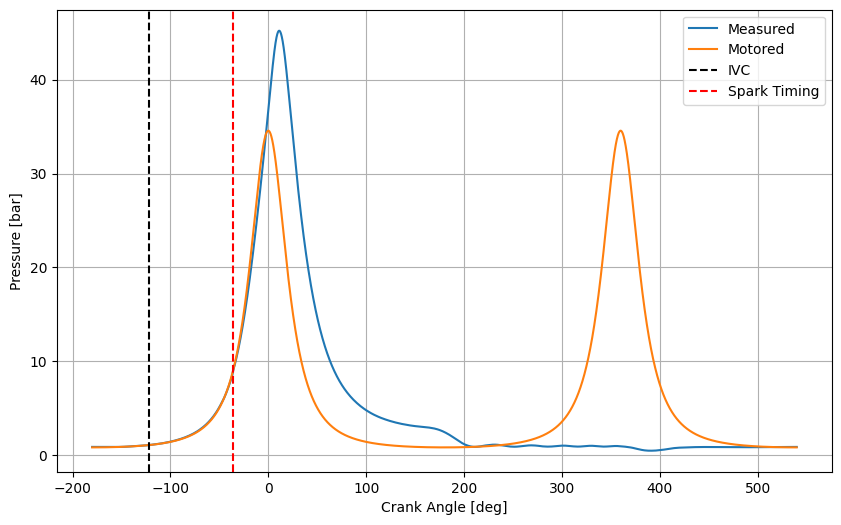

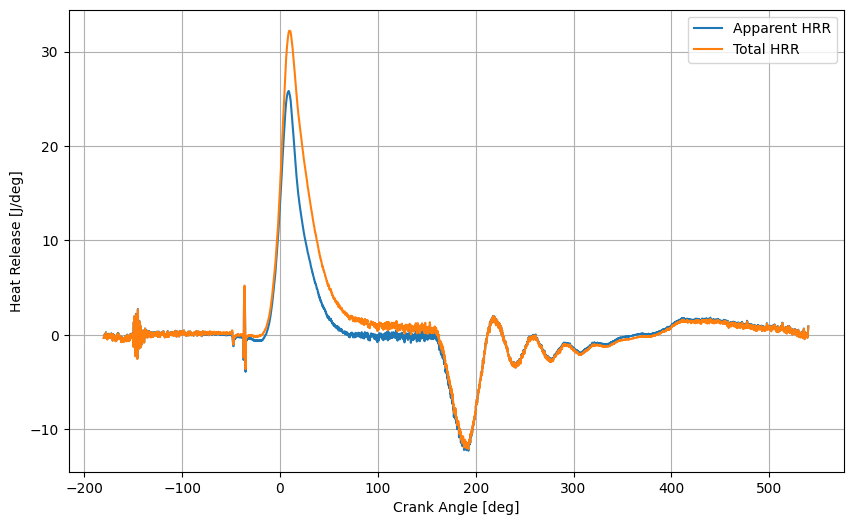

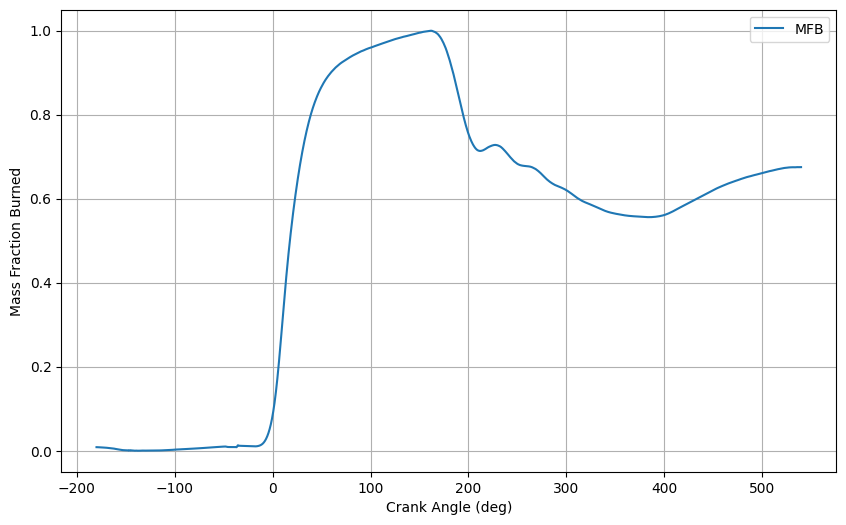

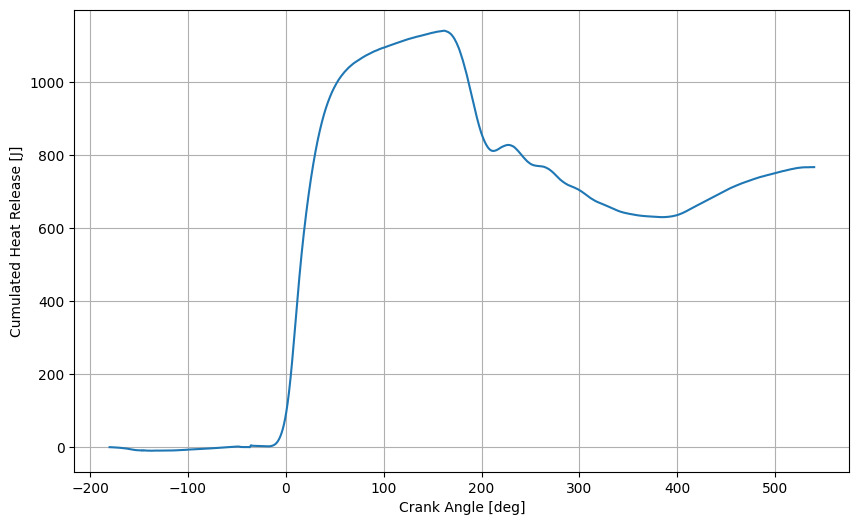

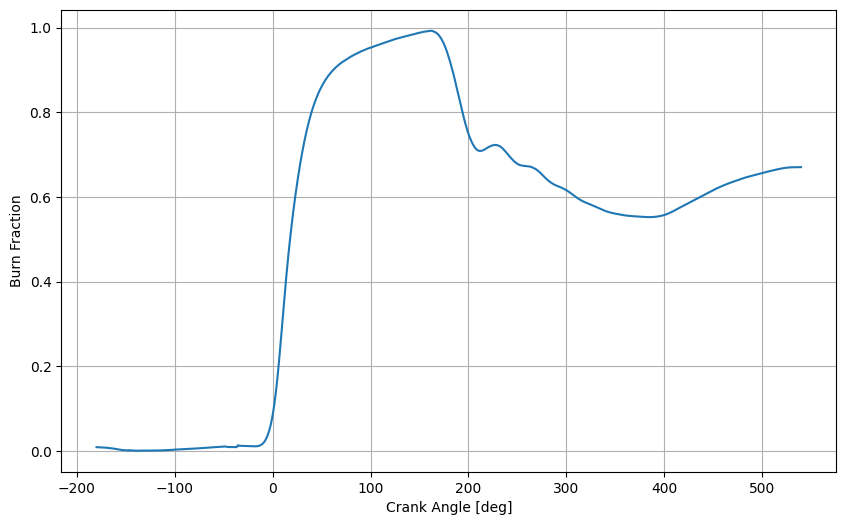

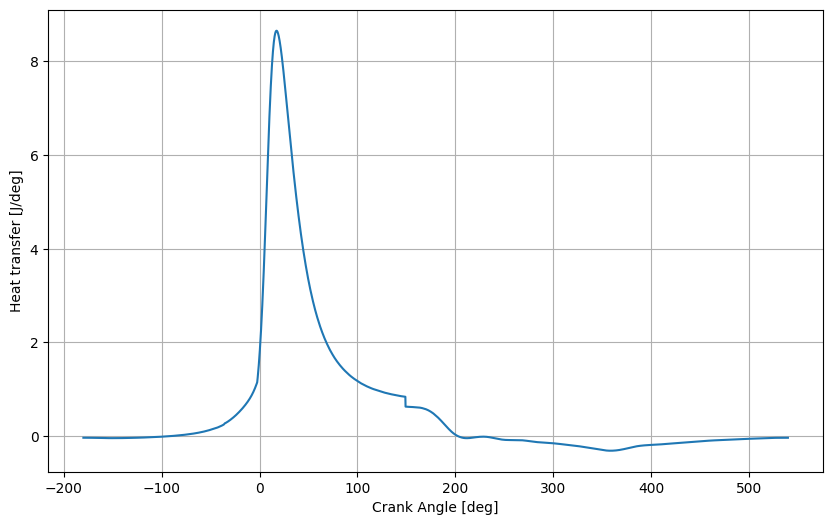

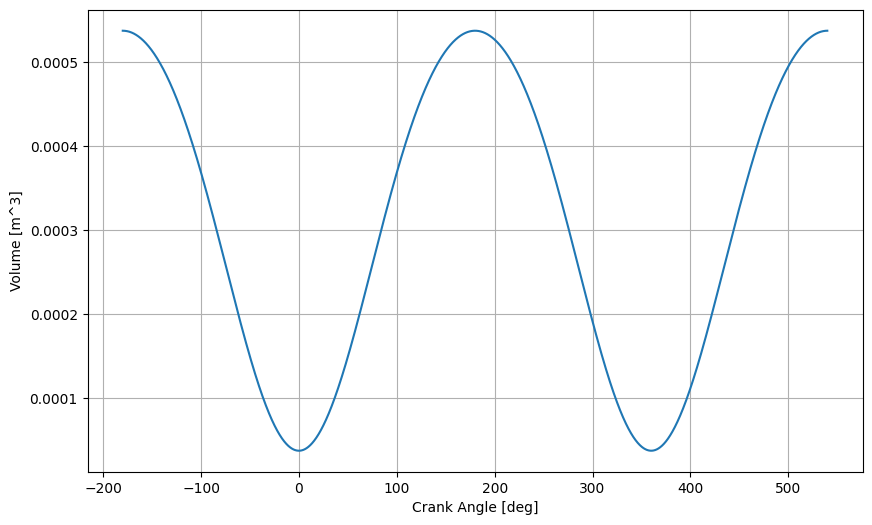

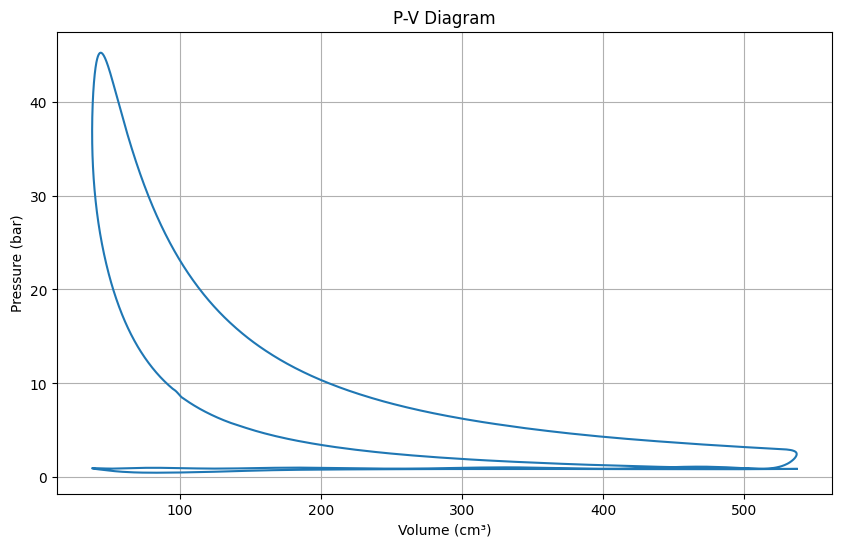

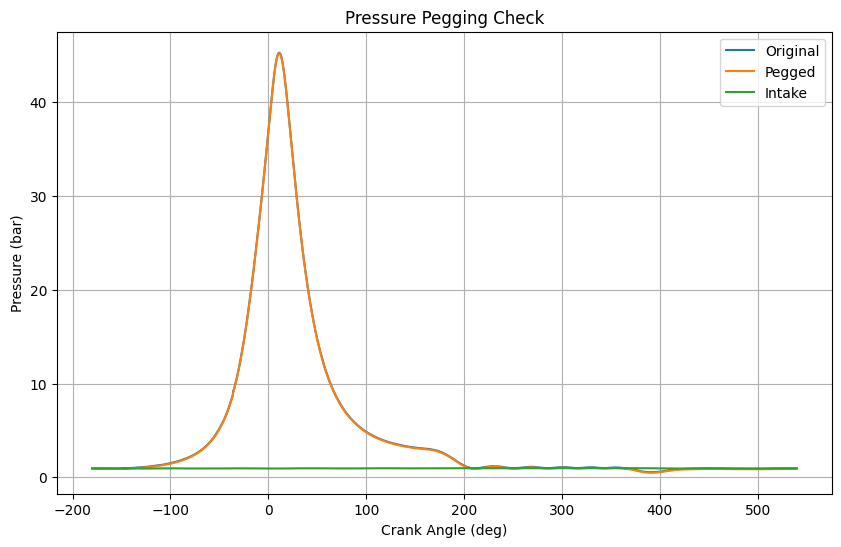

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# INPUT FILE
# ------------------------------------------------

file_path = "AR_MT_251009_15h40m08s_13696.txt"

# ------------------------------------------------
# ENGINE PARAMETERS
# ------------------------------------------------

bore = 0.085
stroke = 0.088
conrod = 0.145
compression_ratio = 14.23

R = 287
Ru = 8.314462618

rpm = 1000
Spark_timing = -36
Twall = 450
IVC = -122
EVO = 149

# ------------------------------------------------
# STANDARD CONDITIONS
# ------------------------------------------------

p_std = 101325
T_std = 273.15

# ------------------------------------------------
# AIR COMPOSITION
# ------------------------------------------------

x_N2 = 0.79
x_O2 = 0.21

M_N2 = 28.0134e-3
M_O2 = 31.9988e-3

M_air = x_N2*M_N2 + x_O2*M_O2

rho_air = p_std*M_air/(Ru*T_std)

# ------------------------------------------------
# FUEL COMPOSITION
# ------------------------------------------------

x_NH3 = 1.0
x_DME = 0.0

M_NH3 = 17.03052e-3
M_DME = 46.06844e-3

M_fuel = x_NH3*M_NH3 + x_DME*M_DME

# mass fractions

w_NH3 = x_NH3*M_NH3/M_fuel
w_DME = x_DME*M_DME/M_fuel

# heating values

LHV_NH3 = 18.6e6
LHV_DME = 28.4e6
LHV_CO  = 10.1e6

LHV_fuel = w_NH3*LHV_NH3 + w_DME*LHV_DME

# fuel density at standard conditions

rho_fuel = p_std*M_fuel/(Ru*T_std)

print("Fuel molar mass:",M_fuel)
print("Fuel LHV:",LHV_fuel/1e6,"MJ/kg")

# ------------------------------------------------
# READ PERFORMANCE DATA
# ------------------------------------------------

with open("performance_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_air = header.index("Air[Nl/min]")
    idx_fuel_nh3 = header.index("NH3[Nl/min]")
    idx_fuel_dme = header.index("DME[Nl/min]")

    air_flow_Lmin = None
    nh3_flow_Lmin = None
    dme_flow_Lmin = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            air_flow_Lmin = float(parts[idx_air])
            nh3_flow_Lmin = float(parts[idx_fuel_nh3])
            dme_flow_Lmin = float(parts[idx_fuel_dme])

            break

# ------------------------------------------------
# VOLUME FLOW INPUT (L/min)
# ------------------------------------------------

fuel_flow_Lmin = nh3_flow_Lmin + dme_flow_Lmin

# ------------------------------------------------
# FLOW CONVERSION
# ------------------------------------------------

air_flow_m3s = air_flow_Lmin/1000/60
fuel_flow_m3s = fuel_flow_Lmin/1000/60

air_mdot = rho_air*air_flow_m3s
fuel_mdot = rho_fuel*fuel_flow_m3s

# ------------------------------------------------
# MASS PER ENGINE CYCLE
# ------------------------------------------------

rev_per_sec = rpm/60
cycles_per_sec = rev_per_sec/2

air_mass_cycle = air_mdot/cycles_per_sec
fuel_mass_cycle = fuel_mdot/cycles_per_sec

m_total = air_mass_cycle + fuel_mass_cycle

fuel_energy = fuel_mass_cycle*LHV_fuel

print("Air mass per cycle:",air_mass_cycle)
print("Fuel mass per cycle:",fuel_mass_cycle)
print("Fuel energy per cycle:",fuel_energy)

# ------------------------------------------------
# GEOMETRY
# ------------------------------------------------

area = np.pi*(bore/2)**2
r = stroke/2
l = conrod

Vs = area*stroke
Vc = Vs/(compression_ratio-1)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

def cylinder_volume(theta):

    th = np.radians(theta)

    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return Vc + area*x

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

def cylinder_area(theta):

    th = np.radians(theta)

    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return 2*area + np.pi*bore*x

# ------------------------------------------------
# GAMMA FUNCTION
# ------------------------------------------------

def gamma_T(T):

    g = 1.38 - 0.0001*(T-300)

    return np.clip(g,1.25,1.40)

# ------------------------------------------------
# WOSCHNI HEAT TRANSFER
# ------------------------------------------------

#def woschni_ht(area,p,T,V):
#
#    B = bore
#
#    Cm = 2*stroke*rpm/60
#
#    C1 = 2.28
#
#    w = C1*Cm
#
#    h = 3.26*(B**-0.2)*((p/1000)**0.8)*(T**-0.55)*(w**0.8)
#
#    Qdot = h*area*(T-Twall)
#
#    Qdeg = Qdot/(6*rpm)
#
#    return Qdeg

# ------------------------------------------------
# EXTENDED WOSCHNI HEAT TRANSFER
# ------------------------------------------------

#def woschni_ht(area,p,T,V,p_mot,C0):
#
#    B = bore
#    Vd = Vs
#
#    Cm = 2*stroke*rpm/60
#
#    C1 = 2.28
#    C2 = 0.00322
#
#    # combustion velocity term
#    w = C1*Cm + C2*(Vd*T/(p*V))*(p-p_mot)
#
#    h = C0*(B**-0.2)*(p/1000)**0.8*(T**-0.53)*(w**0.8)
#
#    Qdot = h*area*(T-Twall)
#
#    Qdeg = Qdot/(6*rpm)
#
#    return Qdeg

def woschni_ht(theta,area,p,T,V,p_mot,C0):

    B = bore
    Vd = Vs

    Cm = 2*stroke*rpm/60

    C1 = 2.28
    C2 = 0.00322

    Qdeg = np.zeros_like(theta)

    for i in range(len(theta)):

        # base gas velocity
        w = C1 * Cm

        # combustion contribution only during combustion
        if Spark_timing <= theta[i] <= EVO:
            
            dp = max(p[i] - p_mot[i],0)
            w += C2 * (Vd * T[i] / (p[i] * V[i])) * dp

        h = C0 * (B**-0.2) * (p[i]/1000)**0.8 * (T[i]**-0.53) * (w**0.8)

        Qdot = h * area[i] * (T[i] - Twall)

        Qdeg[i] = Qdot / (6*rpm)

    return Qdeg

# ------------------------------------------------
# OPTIMIZE C0
# ------------------------------------------------

def optimize_C0(theta,p,T,V,p_mot,HRR_app,comb_eff):

    mask = (theta>=Spark_timing) & (theta<=EVO)

    theta_c = theta[mask]
    HRR_c = HRR_app[mask]

    target_energy = LHV_fuel*fuel_mass_cycle*comb_eff

    best_C0 = 3.26
    best_error = 1e30

    for C0 in np.linspace(0.5,10.0,200):

        Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

        Qw_c = Qw[mask]

        released = np.trapz(HRR_c,theta_c)
        heatloss = np.trapz(Qw_c,theta_c)

        energy = released + heatloss
        print(energy)
        print(target_energy)

        error = abs(energy-target_energy)

        if error < best_error:

            best_error = error
            best_C0 = C0

    print("Optimized C0:",best_C0)

    return best_C0

# ------------------------------------------------
# MOTORED PRESSURE FIT
# ------------------------------------------------

def calculate_motored_pressure(theta, p, V, IVC, Spark_timing):

    idx_ivc = np.argmin(np.abs(theta-IVC))

    p_ivc = p[idx_ivc]
    V_ivc = V[idx_ivc]

    mask = (theta >= IVC) & (theta <= Spark_timing)

    theta_fit = theta[mask]
    p_fit = p[mask]
    V_fit = V[mask]

    best_n = 1.3
    best_error = 1e30

    # search polytropic exponent
    for n in np.linspace(1.20,1.40,200):

        p_model = p_ivc*(V_ivc/V_fit)**n

        error = np.mean((p_fit-p_model)**2)

        if error < best_error:

            best_error = error
            best_n = n

    print("Best polytropic exponent:",best_n)

    # compute full motored curve
    p_mot = p_ivc*(V_ivc/V)**best_n

    return p_mot

# ------------------------------------------------
# LOAD PRESSURE TRACE
# ------------------------------------------------

file_prefix = file_path.replace(".txt", "")
data = pd.read_csv(file_path, sep='\s+')

theta = data["CAD[deg]"].values
p_cyl = data["p_cyl[bar]"].values*1e5
p_intake = data["p_intake[bar]"].values*1e5

# ------------------------------------------------
# PRESSURE PEGGING
# ------------------------------------------------

mask = (theta>-180)&(theta<IVC)

offset = np.mean(p_intake[mask]) - np.mean(p_cyl[mask])

p = p_cyl + offset

# ------------------------------------------------
# FILTER PRESSURE
# ------------------------------------------------

p = savgol_filter(p,21,3)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

V = cylinder_volume(theta)

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

A = cylinder_area(theta)

# ------------------------------------------------
# TEMPERATURE AT IVC
# ------------------------------------------------

idx = np.argmin(np.abs(theta-IVC))

T_ivc = p[idx]*V[idx]/(m_total*R)

print("Temperature at IVC:",T_ivc)

# ------------------------------------------------
# MOTORED PRESSURE
# ------------------------------------------------

p_mot = calculate_motored_pressure(theta,p,V,IVC,Spark_timing)

# ------------------------------------------------
# ITERATIVE HEAT RELEASE SOLVER
# ------------------------------------------------

gamma = np.ones(len(theta))*1.35

for i in range(5):

    dp = np.gradient(p,theta)
    dV = np.gradient(V,theta)

    HRR_app = (gamma/(gamma-1))*p*dV + (1/(gamma-1))*V*dp

    T = p*V/(m_total*R)

    gamma = gamma_T(T)

# ------------------------------------------------
# IMEP
# ------------------------------------------------

work = np.trapz(p, V)
IMEP = work / Vs
print("IMEP (bar):", IMEP/1e5, "bar")

# ------------------------------------------------
# Thermal efficiency
# ------------------------------------------------

eta_therm = (IMEP*Vs)/(LHV_fuel*fuel_mass_cycle)*100
print("Thermal efficiency (%):",eta_therm)

# ------------------------------------------------
# READ EMISSION DATA
# ------------------------------------------------

with open("emission_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_CO = header.index("CO[vol-ppm]")
    idx_NH3 = header.index("NH3[vol-ppm]")
    idx_CH2O = header.index("CH2O[vol-ppm]")
    idx_CH3CHO = header.index("CH3CHO[vol-ppm]")

    X_CO_exhaust = None
    X_NH3_exhaust = None
    X_CH2O_exhaust = None
    X_CH3CHO_exhaust = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            X_CO_exhaust = float(parts[idx_CO])
            X_NH3_exhaust = float(parts[idx_NH3])
            X_CH2O_exhaust = float(parts[idx_CH2O])
            X_CH3CHO_exhaust = float(parts[idx_CH3CHO])

            break

# ------------------------------------------------
# CONVERT TO FRACTIONS
# ------------------------------------------------

X_CO_exhaust = X_CO_exhaust * 1e-6
X_NH3_exhaust = X_NH3_exhaust * 1e-6
X_CH2O_exhaust = X_CH2O_exhaust * 1e-6
X_CH3CHO_exhaust = X_CH3CHO_exhaust * 1e-6

# ------------------------------------------------
# SANITY CHECK FOR OXYGENATES
# ------------------------------------------------

if (X_CH2O_exhaust + X_CH3CHO_exhaust) > X_NH3_exhaust:

    print("The mole fraction of unburned oxygenates is too high")

    X_CH2O_exhaust = 0.0
    X_CH3CHO_exhaust = 0.0

# ------------------------------------------------
# COMBUSTION EFFICIENCY
# ------------------------------------------------

loss_CO = X_CO_exhaust * LHV_CO
loss_NH3 = X_NH3_exhaust * LHV_NH3
loss_oxygenates = (X_CH2O_exhaust + X_CH3CHO_exhaust) * LHV_DME

chemical_loss = loss_CO + loss_NH3 + loss_oxygenates

combustion_efficiency = 1 - chemical_loss / LHV_fuel

print("Combustion efficiency:", combustion_efficiency)

# ------------------------------------------------
# WOSCHNI HEAT TRANSFER
# ------------------------------------------------

#Qw = woschni_ht(A,p,T,V)

# ------------------------------------------------
# OPTIMIZE HEAT TRANSFER PARAMETER
# ------------------------------------------------

C0 = optimize_C0(theta,p,T,V,p_mot,HRR_app,combustion_efficiency)

# compute final heat transfer
Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

# ------------------------------------------------
# TOTAL HEAT RELEASE RATE
# ------------------------------------------------

HRR_total = HRR_app + Qw

# ------------------------------------------------
# CUMULATED HEAT RELEASE
# ------------------------------------------------

CHR = np.cumsum(HRR_total*np.gradient(theta))
CHR_norm = (CHR - np.min(CHR)) / (np.max(CHR) - np.min(CHR))

# ------------------------------------------------
# BURN FRACTION
# ------------------------------------------------

burn_fraction = CHR_norm*combustion_efficiency

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

def find_CA(target):
    idx = np.where(burn_fraction >= target)[0][0]
    return theta[idx]

CA10 = find_CA(0.10)
CA50 = find_CA(0.50)
CA90 = find_CA(0.90)
print("CA10 =", CA10, "deg")
print("CA50 =", CA50, "deg")
print("CA90 =", CA90, "deg")

# ------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------

out = np.column_stack([

theta,
p,
p_mot,
gamma,
T,
HRR_app,
HRR_total,
CHR,
burn_fraction

])

header = "CAD p_filtered p_motored gamma T HRR_app[J/deg] HRR_total[J/deg] CHR[J] burn_fraction"

np.savetxt(file_prefix + "_analysis_results.txt",out,header=header, comments='')

print("Results written to analysis_results.txt")

# ------------------------------------------------
# PLOTS
# ------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(theta,p/1e5,label="Measured")
plt.plot(theta,p_mot/1e5,label="Motored")
# mark important crank angles
plt.axvline(IVC, linestyle="--", color="black", label="IVC")
plt.axvline(Spark_timing, linestyle="--", color="red", label="Spark Timing")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Pressure [bar]")
plt.legend()
plt.grid()

plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta,HRR_app,label="Apparent HRR")
plt.plot(theta,HRR_total,label="Total HRR")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat Release [J/deg]")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, CHR_norm, label="MFB")
plt.axvline(CA10, linestyle="--", label="CA10")
plt.axvline(CA50, linestyle="--", label="CA50")
plt.axvline(CA90, linestyle="--", label="CA90")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Mass Fraction Burned")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta,CHR)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Cumulated Heat Release [J]")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta,burn_fraction)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Burn Fraction")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta,Qw)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat transfer [J/deg]")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta,V)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Volume [m^3]")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(V*1e6, p/1e5)
plt.xlabel("Volume (cm³)")
plt.ylabel("Pressure (bar)")
plt.title("P-V Diagram")
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(theta, p_cyl/1e5, label="Original")
plt.plot(theta, p/1e5, label="Pegged")
plt.plot(theta, p_intake/1e5, label="Intake")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Pegging Check")
plt.legend()
plt.grid()
plt.show()